# check  cdr RMSD 

In [ ]:
import pandas as pd

# CSV 불러오기
path = "/home/psh/BioBetter/5ggs/meta/metadata_dms_filtered.csv"
df = pd.read_csv(path)

# 샘플링 설정
total_valid = 60
neg_valid = int(total_valid * 0.3)  # affinity=-1
pos_valid = total_valid - neg_valid  # affinity != -1

# affinity=-1 샘플에서 valid 선택
df_neg_candidates = df[df['affinity'] == -1]
df_neg_valid = df_neg_candidates.sample(n=min(neg_valid, len(df_neg_candidates)), random_state=42)

# affinity != -1 샘플에서 valid 선택
df_pos_candidates = df[df['affinity'] != -1]
df_pos_valid = df_pos_candidates.sample(n=min(pos_valid, len(df_pos_candidates)), random_state=42)

# valid set 합치기 및 랜덤 섞기
valid_df = pd.concat([df_neg_valid, df_pos_valid]).sample(frac=1, random_state=42).reset_index(drop=True)

# train set = 나머지 row
train_df = df.drop(valid_df.index).reset_index(drop=True)

# CSV 저장
valid_df.to_csv("/home/psh/BioBetter/5ggs/meta/metadata_dms_valid.csv", index=False)
train_df.to_csv("/home/psh/BioBetter/5ggs/meta/metadata_dms_train.csv", index=False)

# 확인
print("Valid set:", len(valid_df), "row")
print(" - affinity=-1:", (valid_df['affinity'] == -1).sum())
print("Train set:", len(train_df), "row")


### 각 pdb별 샘플들의 h3 cdr RMSD 분포 체크

In [ ]:
import os
import json
import time
import traceback
import pandas as pd
import numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed
from Bio.PDB import PDBParser


# ============================================================
# 0. 공용 함수
# ============================================================

def load_first_chain_coords(pdb_file):
    """PDB의 첫 번째 체인 residue_id → CA 좌표 dict 반환"""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("x", pdb_file)
    model = structure[0]

    first_chain = list(model.get_chains())[0]

    coords = {}
    for residue in first_chain:
        res_id = residue.get_id()[1]
        if "CA" in residue:
            coords[res_id] = residue["CA"].get_coord()
    return coords


def vectorized_rmsd(ref_coords, tgt_coords, start, end):
    """vectorized RMSD 계산"""
    ids = np.arange(start, end + 1)

    ref = np.array([ref_coords.get(r, None) for r in ids], dtype=object)
    tgt = np.array([tgt_coords.get(r, None) for r in ids], dtype=object)

    mask = np.array([(r is not None and t is not None) for r, t in zip(ref, tgt)])
    
    rmsd = np.full(len(ids), None, dtype=object)
    if mask.any():
        diff = np.vstack(ref[mask]) - np.vstack(tgt[mask])
        rmsd_values = np.sqrt(np.sum(diff * diff, axis=1))
        rmsd[mask] = rmsd_values.tolist()

    return {res_id: rmsd[i] for i, res_id in enumerate(ids)}


# ============================================================
# 1. base_dir 추출
# ============================================================

csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/6wgl_insert/plddt/plddt.csv'
pdb_id = '6wgl_A_B_C'

base_dir = os.path.dirname(os.path.dirname(csv_file))
print("[base_dir]", base_dir)


# ============================================================
# 2. CSV load + 전처리(벡터화)
# ============================================================

df = pd.read_csv(csv_file)
df['h_avg'] = df[['h1_plddt', 'h2_plddt', 'h3_plddt']].mean(axis=1)

best_rows = df.loc[df.groupby('mt_id')['h_avg'].idxmax()].reset_index(drop=True)
best_rows['pure_mt_id'] = best_rows['mt_id'].str.replace(f'{pdb_id}_', '', regex=False)

def extract_numbers(x):
    if x == pdb_id:
        return []
    return [int(p[1:]) for p in x.split('_') if p.startswith('A')]

best_rows['num_list'] = best_rows['pure_mt_id'].apply(extract_numbers)
best_rows['h1_count'] = best_rows['num_list'].apply(lambda x: sum(25 <= n <= 32 for n in x))
best_rows['h2_count'] = best_rows['num_list'].apply(lambda x: sum(51 <= n <= 57 for n in x))


# ============================================================
# 3. ref 좌표 로딩
# ============================================================

ref_row = best_rows[best_rows['mt_id'] == pdb_id]
ref_file_path = os.path.join(base_dir, pdb_id, ref_row.iloc[0]['sample_id'], "sample_1.pdb")
ref_coords = load_first_chain_coords(ref_file_path)


# ============================================================
# 4. 병렬 작업 함수 정의
# ============================================================

def process_one_row(row):
    """각 row를 처리하고 (성공 여부, 로그 메시지, 출력 파일) 반환"""
    try:
        mt_id = row['mt_id']
        sample_id = row['sample_id']
        h1_count = row['h1_count']
        h2_count = row['h2_count']

        file_path = os.path.join(base_dir, mt_id + ".pkl", sample_id, "sample_1.pdb")
        if not os.path.exists(file_path):
            return (False, f"[MISS] {file_path} not found", None)

        tgt_coords = load_first_chain_coords(file_path)

        # CDR index 정의
        cdr_h1 = (26, 32 + h1_count)
        cdr_h2 = (52 + h1_count, 57 + h1_count + h2_count)

        # RMSD 계산
        h1_rmsd = vectorized_rmsd(ref_coords, tgt_coords, *cdr_h1)
        h2_rmsd = vectorized_rmsd(ref_coords, tgt_coords, *cdr_h2)

        # 저장
        out_dir = os.path.join(base_dir, mt_id, sample_id)
        os.makedirs(out_dir, exist_ok=True)
        out_json = os.path.join(out_dir, "rmsd_info.json")

        with open(out_json, 'w') as f:
            json.dump({
                "h1_rmsd": h1_rmsd,
                "h2_rmsd": h2_rmsd
            }, f, indent=4)

        return (True, f"[OK] {mt_id} | {sample_id}", out_json)

    except Exception as e:
        msg = traceback.format_exc()
        return (False, msg, None)


# ============================================================
# 5. 병렬 실행 + 전체 진행 상황 표시
# ============================================================

rows = best_rows.to_dict(orient="records")
total = len(rows)

print(f"\n[START] Total rows = {total}\n")

start_time = time.time()
completed = 0

error_log_path = os.path.join(base_dir, "error_log.txt")
error_log = open(error_log_path, "w")

with ProcessPoolExecutor(max_workers=16) as exe:
    futures = {exe.submit(process_one_row, row): row for row in rows}

    for future in as_completed(futures):
        ok, msg, out_json = future.result()
        completed += 1

        # 진행률 계산
        pct = completed / total * 100
        elapsed = time.time() - start_time
        eta = (elapsed / completed) * (total - completed)

        if ok:
            print(f"[{completed}/{total}] ({pct:5.1f}%)  ETA {eta:6.1f}s  {msg}")
        else:
            print(f"[ERR] {msg[:100]} ...")
            error_log.write(msg + "\n\n")

error_log.close()
print("\n[COMPLETE] All tasks finished.")
print(f"[ERROR LOG] saved at {error_log_path}")


## 각 pdb에서 상위 10위 추출

In [ ]:
# 각 PDB에서 상위 10개 RMSD 값 저장
import numpy as np
import os 
import json 

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/benchmark'
h3_rmsd_by_pdb = {}
top_10_rmsd_by_pdb = {}
top_rank = 25

pdb_ids = []
for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    for sample in os.listdir(sub_dir):
        if 'sample' not in sample:
            continue
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
    
    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  


for pdb, rmsd_list in h3_rmsd_by_pdb.items():
    sorted_rmsd = sorted(rmsd_list, reverse=False)  # 내림차순 정렬
    top_10_rmsd_by_pdb[pdb] = sorted_rmsd[top_rank-1]  # 상위 10개 선택

# 결과 확인 (예시 출력)
top_rmsds = []
for pdb, top_rmsd in list(top_10_rmsd_by_pdb.items()):  # 상위 5개만 출력
    top_rmsds.append(top_rmsd)

print(np.mean(top_rmsds))

### confidence metric과 h3 rmsd 간의 correlation 

In [ ]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from concurrent.futures import ProcessPoolExecutor, as_completed

# ============================================================
# 1️⃣ CSV load + 전처리
# ============================================================
csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/6wgl_insert/plddt/plddt.csv'
pdb_id = '6wgl_A_B_C'
base_dir = os.path.dirname(os.path.dirname(csv_file))

df = pd.read_csv(csv_file)
df['h_avg'] = df[['h1_plddt', 'h2_plddt', 'h3_plddt']].mean(axis=1)
best_rows = df.loc[df.groupby('mt_id')['h_avg'].idxmax()].reset_index(drop=True)
best_rows['pure_mt_id'] = best_rows['mt_id'].str.replace(f'{pdb_id}_', '', regex=False)

def extract_numbers(x):
    if x == pdb_id:
        return []
    return [int(p[1:]) for p in x.split('_') if p.startswith('A')]

best_rows['num_list'] = best_rows['pure_mt_id'].apply(extract_numbers)
best_rows['h1_count'] = best_rows['num_list'].apply(lambda x: sum(25 <= n <= 32 for n in x))
best_rows['h2_count'] = best_rows['num_list'].apply(lambda x: sum(51 <= n <= 57 for n in x))

# ============================================================
# 2️⃣ RMSD 벡터화 함수
# ============================================================
def load_rmsd_vector(rmsd_path, residue_range=None):
    with open(rmsd_path, 'r') as f:
        rmsd_info = json.load(f)
    if residue_range is None:
        residue_range = sorted(map(int, rmsd_info.keys()))
    vec = np.array([rmsd_info.get(str(r), np.nan) for r in residue_range], dtype=float)
    return vec

# ============================================================
# 3️⃣ 그룹별 처리 함수 (t-SNE 버전)
# ============================================================
def process_group(group_tuple):
    (h1c, h2c), group = group_tuple
    rmsd_vectors = []
    valid_indices = []
    residue_range = None

    for idx, row in group.iterrows():
        # rmsd 경로 지정
        if row['mt_id'] == '6wgl_A_B_C':
            rmsd_path = os.path.join(base_dir, row['mt_id'], row['sample_id'], "rmsd_info.json")
        else:
            rmsd_path = os.path.join(base_dir, row['mt_id'] + '.pkl', row['sample_id'], "_rmsd.json")

        if not os.path.exists(rmsd_path):
            continue
        vec = load_rmsd_vector(rmsd_path)
        if residue_range is None:
            residue_range = sorted(range(len(vec)))
        rmsd_vectors.append(vec)
        valid_indices.append(idx)

    if len(rmsd_vectors) < 2:
        return None

    X = np.vstack(rmsd_vectors)
    
    # 차원 축소 (t-SNE)
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(X)-1))
    X_emb = tsne.fit_transform(X)
    
    # 클러스터링
    n_clusters = min(5, len(X))
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_emb)

    result_group = group.loc[valid_indices].copy()
    result_group['cluster_id'] = labels
    return result_group

# ============================================================
# 4️⃣ 멀티프로세싱
# ============================================================
cluster_results = []

with ProcessPoolExecutor(max_workers=36) as executor:
    futures = [executor.submit(process_group, g) for g in best_rows.groupby(['h1_count', 'h2_count'])]
    for fut in as_completed(futures):
        res = fut.result()
        if res is not None:
            cluster_results.append(res)

# 최종 CSV 저장
if cluster_results:
    final_df = pd.concat(cluster_results, ignore_index=True)
    out_csv = os.path.join(base_dir, 'plddt', 'clustered_results.csv')
    final_df.to_csv(out_csv, index=False)
    print("Clustered CSV saved to:", out_csv)
else:
    print("No clustering results")


### 6 cdr plddt를 적절히 combination해서 설명력 좋은 metric으로 만들기 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from scipy.optimize import differential_evolution
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing
import os

# =======================
# 1️⃣ 데이터 로드 및 준비
# =======================
input_csv = '/home/psh/cdr_bfactor_h3_rmsd_samples.csv'
output_metric_csv = '/home/psh/cdr_plddt_metric_with_pdb_corr.csv'
output_weight_csv = '/home/psh/plddt_feature_weights.csv'

df = pd.read_csv(input_csv)

features = [f'{cdr}_plddt' for cdr in ['h1','h2','h3','l1','l2','l3']]
target = 'h3_rmsd'

df = df.dropna(subset=features + [target])
print(f"✅ 유효 샘플 수: {len(df)}")

# 스케일링
scaler = StandardScaler()
X = scaler.fit_transform(df[features].values)
y = df[target].values

# =======================
# 2️⃣ 하위 RMSD 강조 (가중 목적)
# =======================
threshold = np.percentile(y, 25)
low_mask = y <= threshold

# =======================
# 3️⃣ 목적 함수 정의
# =======================
def metric_score(weights):
    metric = X.dot(weights)
    corr_full, _ = spearmanr(metric, y)
    corr_low, _ = spearmanr(metric[low_mask], y[low_mask])
    # 낮은 RMSD(좋은 샘플)에 더 높은 가중치
    score = 0.7 * corr_low + 0.3 * corr_full
    return -score  # maximize → minimize(-score)

# =======================
# 4️⃣ Differential Evolution 최적화
# =======================
bounds = [(-2, 2)] * len(features)
result = differential_evolution(
    metric_score,
    bounds,
    maxiter=300,
    popsize=30,
    tol=1e-6,
    polish=True,
    seed=42,
    updating="deferred",  # 병렬 최적화
    workers=-1             # 모든 CPU 코어 사용
)

opt_weights = result.x / np.linalg.norm(result.x)
df['metric'] = X.dot(opt_weights)

# =======================
# 5️⃣ 전체 / 하위 25% 상관관계 평가
# =======================
corr_full, _ = spearmanr(df['metric'], y)
corr_low, _ = spearmanr(df.loc[low_mask, 'metric'], df.loc[low_mask, target])

print("\n✅ 최적화 완료!")
for f, w in zip(features, opt_weights):
    print(f"{f:<20} {w:+.3f}")
print(f"\n📈 전체 Spearman: {corr_full:.3f}")
print(f"🎯 하위 25% Spearman: {corr_low:.3f}")

# =======================
# 6️⃣ 각 PDB별 Spearman 계산 (병렬)
# =======================
def compute_pdb_corr(pdb_id, sub_df):
    """개별 pdb의 Spearman 계산 함수"""
    if len(sub_df) < 3:
        return pdb_id, np.nan
    corr, _ = spearmanr(sub_df['metric'], sub_df[target])
    return pdb_id, corr

pdb_groups = list(df.groupby('pdb_id'))

print(f"⚙️ {len(pdb_groups)}개 PDB에 대해 Spearman 계산 중... (multi-CPU)")

spearman_results = []
with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
    futures = {executor.submit(compute_pdb_corr, pdb, sub): pdb for pdb, sub in pdb_groups}
    for future in as_completed(futures):
        pdb_id, corr = future.result()
        spearman_results.append((pdb_id, corr))

spearman_df = pd.DataFrame(spearman_results, columns=['pdb_id', 'pdb_spearman'])
df_with_corr = df.merge(spearman_df, on='pdb_id', how='left')

# =======================
# 7️⃣ 결과 저장
# =======================
df_with_corr.to_csv(output_metric_csv, index=False)
print(f"💾 Spearman 결과 저장: {output_metric_csv}")

weight_df = pd.DataFrame({
    'feature': features,
    'weight': opt_weights
})
weight_df.to_csv(output_weight_csv, index=False)
print(f"💾 가중치 저장: {output_weight_csv}")

print("\n✅ 모든 작업 완료!")


## 각 pdb에서 confidence 기반 Top N 뽑기 

In [ ]:
# 각 PDB에서 상위 10개 RMSD 값 저장
import numpy as np
import os 
import json 
from Bio.PDB import PDBParser

cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_path, start_residue=95, end_residue=102):

    parser = PDBParser(QUIET=True)


    structure = parser.get_structure("structure", pdb_path)
    
    # 첫 번째 체인 추출
    first_chain = next(iter(structure[0].get_chains()))
    b_factors = []
    for residue in first_chain:
        residue_id = residue.get_id()
        if residue_id[0] == " ":  # 표준 아미노산만 고려
            residue_number = residue_id[1]
            if start_residue <= residue_number <= end_residue:
                for atom in residue:
                    b_factors.append(atom.get_bfactor())
            
    b_factors_avg = np.mean(b_factors)

    return b_factors_avg

pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_only_plddt/2025-11-09_00-08-56/epoch=27-step=40124/run_2025-11-10_19-36-04'
h3_rmsd_by_pdb = {}
b_factors_by_pdb = {}
top_n_rmsd_by_pdb = {}
top_rank = 1

pdb_ids = []
for pdb_id in os.listdir(pred_dir):
    if 'config' in pdb_id:
        continue  # 설정 파일은 건너뜀

    pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
    pdb_ids.append(pdb_key)  # 🔹 PDB ID 리스트에 추가

    # 현재 프로젝트에서 RMSD 값 불러오기
    sub_dir = os.path.join(pred_dir, pdb_id)
    h3_cdrs = []
    h3_b_factors = []
    for sample in os.listdir(sub_dir):
        if 'sample' not in sample:
            continue
        cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
        pdb_path = os.path.join(sub_dir, sample, "sample_1.pdb")
        with open(cdr_info, 'r') as f:
            data = json.load(f)
        h3_cdrs.append(data['h3_rms'])
        h3_b_factors.append(calculate_b_factor_mean(pdb_path))

    h3_rmsd_by_pdb[pdb_key] = h3_cdrs  
    b_factors_by_pdb[pdb_key] = h3_b_factors

for pdb, rmsd_list in h3_rmsd_by_pdb.items():
    b_factors = b_factors_by_pdb[pdb]
    top_n_b_factor = sorted(b_factors, reverse=True)[top_rank-1]
    top_n_index = b_factors.index(top_n_b_factor)
    top_n_rmsd_by_pdb[pdb] = rmsd_list[top_n_index] 

# 결과 확인 (예시 출력)
top_rmsds = []
for pdb, top_rmsd in list(top_n_rmsd_by_pdb.items()):  # 상위 5개만 출력
    top_rmsds.append(top_rmsd)

print(np.mean(top_rmsds))

### 각 모델 별 rmsd 비교 

In [ ]:
import os 
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind

pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/WT',
    '/home/psh/af3_output_processed/'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
h3_rmsd_by_pdb_prev = {}
h3_rmsd_by_pdb_af3 = {}

# PDB ID 수집
all_pdb_ids = set()

for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue  # 설정 파일은 건너뜀

        pdb_key = pdb_id.split('_')[0]  # PDB ID 정리
        all_pdb_ids.add(pdb_key)

        # 현재 프로젝트에서 RMSD 값 불러오기
        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        for sample in os.listdir(sub_dir):
            if 'sample' not in sample:
                continue
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            with open(cdr_info, 'r') as f:
                data = json.load(f)
            h3_cdrs.append(data['h3_rms'])

        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs  

# h3 length 길이 순으로 pdb name 정렬 
df = pd.read_csv(csv_path)
df["h3_diff"] = df["h3_end"] - df["h3_start"]
df_sorted = df.sort_values(by="h3_diff", ascending=True)
sorted_pdb_ids = df_sorted["pdb_name"].tolist()
sorted_pdb_ids = [filename.split('_')[0] for filename in sorted_pdb_ids if filename.split('_')[0] in all_pdb_ids]

# PDB ID를 3등분
num_splits = 2
split_size = len(sorted_pdb_ids) // num_splits
split_pdb_ids = [sorted_pdb_ids[i * split_size:(i + 1) * split_size] for i in range(num_splits - 1)]
split_pdb_ids.append(sorted_pdb_ids[(num_splits - 1) * split_size:])  # 마지막 부분 추가

# 색상 설정
colors = ['blue', 'orange']
handles = [
    mpatches.Patch(
        color=colors[idx],
        label=dir.split('/')[5] if len(dir.split('/')) > 5 else dir.split('/')[3]
    )
    for idx, dir in enumerate(pred_dirs)
]

# 📌 그래프 그리기 (3개로 분할)
# 📌 그래프 그리기 (2개로 분할)
for i, pdb_subset in enumerate(split_pdb_ids):
    plt.figure(figsize=(12, 6))

    tenth_values = {pred_dirs[0]: [], pred_dirs[1]: []}

    for idx, pred_dir in enumerate(pred_dirs):
        h3_rmsd_sorted = [h3_rmsd_by_pdb[pred_dir].get(pdb, []) for pdb in pdb_subset]

        # 박스플롯 그리기
        boxplot = plt.boxplot(h3_rmsd_sorted, positions=np.arange(len(pdb_subset)) + (idx * 0.2), widths=0.2,
                              patch_artist=True, boxprops=dict(facecolor=colors[idx], alpha=0.5),
                              medianprops=dict(color='black'))

        # 각 PDB에 대해 낮은 것부터 10번째 값을 저장
        for rmsd_list in h3_rmsd_sorted:
            sorted_rmsd = sorted(rmsd_list)
            if len(sorted_rmsd) >= 10:
                tenth_value = sorted_rmsd[9]  # 인덱스는 0부터 시작하므로 10번째 값은 인덱스 9
            else:
                tenth_value = None  # 또는 np.nan
            tenth_values[pred_dir].append(tenth_value)

    # 중앙값 비교 후 색상 결정
    xlabel_colors = []
    for j, pdb in enumerate(pdb_subset):
        if tenth_values[pred_dirs[0]][j] < tenth_values[pred_dirs[1]][j]:
            xlabel_colors.append(colors[0])  # 첫 번째 모델 색상
        else:
            xlabel_colors.append(colors[1])  # 두 번째 모델 색상

    # 📌 PDB ID의 색상 
    plt.xticks(range(len(pdb_subset)), pdb_subset, rotation=90)  # color 제거

    # 📌 x축 레이블 개별적으로 색상 설정
    ax = plt.gca()  # 현재 축 가져오기
    for label, color in zip(ax.get_xticklabels(), xlabel_colors):
        label.set_color(color)


    # 그래프 설정
    plt.xlabel("PDB ID")
    plt.ylabel("H3 CDR RMSD")
    plt.title(f"H3 CDR RMSD by PDB ID (Part {i+1})")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(handles=handles)

    # 그래프 표시
    plt.show()



# check self-confidence correlation 

## by sample 

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB import PDBParser

from scipy.stats import spearmanr

cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_dir, cdr_type):
    pdb_paths = []
    b_factors_avg = []
    parser = PDBParser(QUIET=True)

    start_residue = cdr_chothia[cdr_type][0]
    end_residue = cdr_chothia[cdr_type][1]
    # 디렉터리 내의 모든 PDB 파일 순회
    for sample in sorted(os.listdir(pdb_dir)):
        pdb_file = os.path.join(pdb_dir, sample, 'sample_1.pdb')
        pdb_paths.append(pdb_file)
        pdb_path = os.path.join(pdb_dir, pdb_file)
        structure = parser.get_structure("structure", pdb_path)
        
        # 첫 번째 체인 추출
        first_chain = next(iter(structure[0].get_chains()))
        b_factors = []
        for residue in first_chain:
            residue_id = residue.get_id()
            if residue_id[0] == " ":  # 표준 아미노산만 고려
                residue_number = residue_id[1]
                if start_residue <= residue_number <= end_residue:
                    # 각 원자의 B-factor 가져오기
                    for atom in residue:
                        b_factors.append(atom.get_bfactor())

        b_factors_avg.append(np.mean(b_factors))
        
    return b_factors_avg, pdb_paths

# PDB 디렉터리 설정
cdr_type = "h1"
pdb_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-10-29_12-41-30/7u8g_D_E_A'
pdb_id = pdb_dir.split('/')[-1]
b_factors, pdb_paths = calculate_b_factor_mean(pdb_dir, cdr_type=cdr_type)

# RMSD 값 수집

cdr_rmsd_dir = pdb_dir
rmsd_values = []

json_paths = []
for sample in sorted(os.listdir(cdr_rmsd_dir)):

    json_file = os.path.join(cdr_rmsd_dir, sample, 'cdr_rmsd.json')
    json_paths.append(json_file)
    # JSON 파일에서 RMSD 데이터 읽기
    with open(json_file, 'r') as f:
        rmsd_data = json.load(f)

    cdr_rmsd = rmsd_data.get(f'{cdr_type}_rms', None)  # 'h3_rms' 키에서 RMSD 값 가져옴
    if cdr_rmsd is not None:
        rmsd_values.append(cdr_rmsd)



correlation_coefficient = spearmanr(rmsd_values, b_factors)

# scatter plot 그리기
plt.figure(figsize=(8, 6))
plt.scatter(rmsd_values, b_factors, color='blue', alpha=0.7)
x_pos = np.mean(rmsd_values) + (max(rmsd_values) - min(rmsd_values)) * 0.3
y_pos = np.mean(b_factors) + (max(b_factors) - min(b_factors)) * 0.3
plt.text(x_pos, y_pos,
         f"Spearman r = {correlation_coefficient[0]:.2f}\n"
         f"p = {correlation_coefficient[1]:.2e}",
         fontsize=12, color='red',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# 플롯 세부 설정
plt.title(f"Self-Confidence Correlation ({pdb_id})")
plt.xlabel(f"{cdr_type} RMSD")
plt.ylabel("pLDDT")
plt.grid(True)
plt.show()



## all inference output 

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from Bio.PDB import PDBParser

from scipy.stats import spearmanr

cdr_chothia = {
    "h1": (26, 32),
    "h2": (52, 56),
    "h3": (95, 102),
    "l1": (24, 34),
    "l2": (50, 56),
    "l3": (89, 97)
}

def calculate_b_factor_mean(pdb_dir, cdr_type):
    pdb_paths = []
    b_factors_avg = []
    parser = PDBParser(QUIET=True)

    start_residue = cdr_chothia[cdr_type][0]
    end_residue = cdr_chothia[cdr_type][1]
    # 디렉터리 내의 모든 PDB 파일 순회
    for pdb in sorted(os.listdir(pdb_dir)):
        if 'config' in pdb:
            continue 
        
        print(f"{pdb} b_factor")
        pdb_path = os.path.join(pdb_dir, pdb)
        for sample in os.listdir(pdb_path):
            if "sample" not in sample:
                continue


            pdb_file = os.path.join(pdb_path, sample, 'sample_1.pdb')
            pdb_paths.append(pdb_file)
            structure = parser.get_structure("structure", pdb_file)
            
            # 첫 번째 체인 추출
            first_chain = next(iter(structure[0].get_chains()))
            b_factors = []
            for residue in first_chain:
                residue_id = residue.get_id()
                if residue_id[0] == " ":  # 표준 아미노산만 고려
                    residue_number = residue_id[1]
                    if start_residue <= residue_number <= end_residue:
                        # 각 원자의 B-factor 가져오기
                        for atom in residue:
                            b_factors.append(atom.get_bfactor())

            b_factors_avg.append(np.mean(b_factors))
        
    return b_factors_avg, pdb_paths

# PDB 디렉터리 설정
cdr_type = "h3"
pdb_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-10-29_12-41-30'
b_factors, pdb_paths = calculate_b_factor_mean(pdb_dir, cdr_type=cdr_type)

# RMSD 값 수집

rmsd_values = []
json_paths = []
for pdb in sorted(os.listdir(pdb_dir)):
    if 'config' in pdb:
        continue 
    print(f"{pdb} rmsd")
    pdb_path = os.path.join(pdb_dir, pdb)
    for sample in os.listdir(pdb_path):
        if "sample" not in sample:
            continue

        json_file = os.path.join(pdb_path, sample, 'cdr_rmsd.json')
        json_paths.append(json_file)
        # JSON 파일에서 RMSD 데이터 읽기
        with open(json_file, 'r') as f:
            rmsd_data = json.load(f)

        cdr_rmsd = rmsd_data.get(f'{cdr_type}_rms', None)  # 'h3_rms' 키에서 RMSD 값 가져옴
        if cdr_rmsd is not None:
            rmsd_values.append(cdr_rmsd)


correlation_coefficient = spearmanr(rmsd_values, b_factors)

# scatter plot 그리기
plt.figure(figsize=(8, 6))
plt.scatter(rmsd_values, b_factors, color='blue', alpha=0.5)
x_pos = np.mean(rmsd_values) + (max(rmsd_values) - min(rmsd_values)) * 0.3
y_pos = np.mean(b_factors) + (max(b_factors) - min(b_factors)) * 0.3
plt.text(x_pos, y_pos,
         f"Spearman r = {correlation_coefficient[0]:.2f}\n"
         f"p = {correlation_coefficient[1]:.2e}",
         fontsize=12, color='red',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
# 플롯 세부 설정
plt.title(f"Self-Confidence Correlation ({pdb_id})")
plt.xlabel(f"{cdr_type} RMSD")
plt.ylabel("pLDDT")
plt.grid(True)
plt.show()



# CDF 형태의 plot

config.yaml
7df1_F_J_C
7ox1_A_B_G
7q6c_H_L_A
7quh_H_L_A
7sbd_H_L_C
7tpg_H_L_B
7tuf_A_B_C
7tzh_C_Z_D
7u8g_D_E_A
7uij_H_L_CD
7ura_H_L_A
7vgr_D_C_AB
7w71_I_M_B
7yix_D_Z_AB
7yru_H_L_A
7z12_B_C_A
7zlh_H_L_A
7zxk_J_I_AB
8aci_H_L_A
8ath_E_F_B
8b7h_H_L_AB
8bw0_H_L_C
8c7m_C_D_B
8cz5_H_L_A
8d0a_H_L_A
8d9y_B_A_I
8db4_A_B_E
8dcn_D_E_F
8djg_C_D_E
8djm_H_L_BA
8dn7_D_H_E
8f5i_X_Y_A
8f5n_H_L_A
8f6o_A_B_C
8gkl_H_L_E
8hpk_H_L_A
8hs2_B_C_R
8j80_E_C_AB
8jel_C_D_J
8jnk_I_M_A
8oxv_B_C_A
8pg0_H_L_A
8q3j_C_B_A
8r9y_B_C_A
8rz0_F_Z_E
8scx_H_L_ABC
8sgj_H_L_A
8sic_A_B_E
8slb_H_L_A
8smm_H_L_A
8t03_C_D_AB
8t05_C_D_AB
8tco_F_G_ABC
8tg9_E_F_B
8tqi_H_L_AB
8ulf_H_L_AB
8urf_H_L_A
8vvl_H_L_A
9ima_C_D_AB


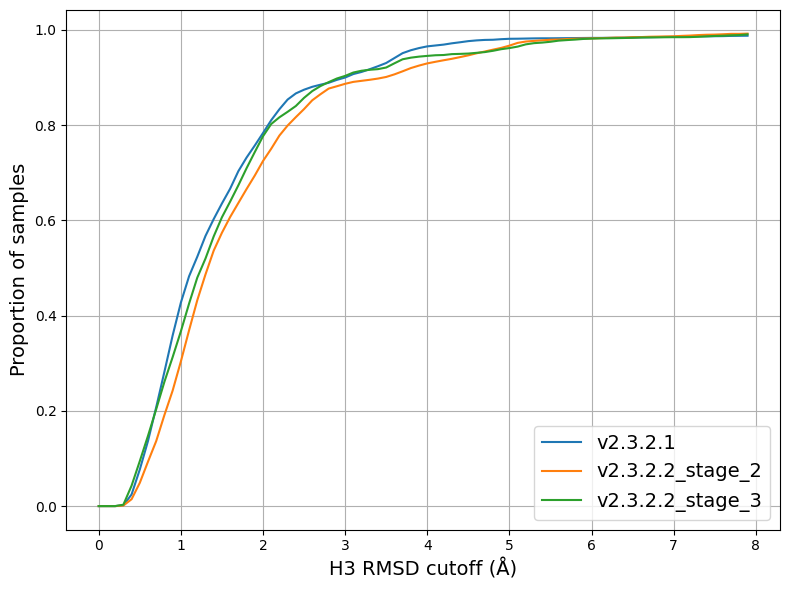

In [1]:
pred_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/benchmark'
af3_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_ori_perturb_stage2/2025-12-05_16-29-09/epoch=45-step=65918_copy/run_2025-12-09_00-04-29'
pred_dir_wo_atom = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/run_2025-12-09_00-00-29'
pred_new_dir = '/home/psh/af3_output_processed/'
import os 
import json 

pred_cdrs = []
pred_wo_atom = []
af3_cdrs = []
pred_new_cdrs = []
for pdb in os.listdir(pred_dir):
    print(pdb)
    if 'config' in pdb:
        continue
    af3_pdb = os.path.join(af3_dir, pdb)
    pred_pdb = os.path.join(pred_dir, pdb)
    pred_wo_atom_pdb = os.path.join(pred_dir_wo_atom, pdb)
    pred_new_pdb = os.path.join(pred_new_dir, pdb)
    for sample in os.listdir(pred_pdb):
        if 'sample' not in sample:
            continue
        pred_cdr_json = os.path.join(pred_pdb, sample, "cdr_rmsd.json")
        af3_cdr_json = os.path.join(af3_pdb, sample, "cdr_rmsd.json")
        pred_wo_atom_json = os.path.join(pred_wo_atom_pdb, sample, "cdr_rmsd.json")
        pred_new_json = os.path.join(pred_new_pdb, sample, "cdr_rmsd.json")

        with open(pred_cdr_json, 'r') as f:
            pred_cdr_data = json.load(f)
        pred_cdrs.append(pred_cdr_data['h3_rms'])

        with open(af3_cdr_json, 'r') as f:
            af3_cdr_data = json.load(f)
        af3_cdrs.append(af3_cdr_data['h3_rms'])

        with open(pred_wo_atom_json, 'r') as f:
            pred_wo_atom_cdr_data = json.load(f)
        pred_wo_atom.append(pred_wo_atom_cdr_data['h3_rms'])

        with open(pred_new_json, 'r') as f:
            pred_new_cdr_data = json.load(f)
        pred_new_cdrs.append(pred_new_cdr_data['h3_rms'])
import matplotlib.pyplot as plt
import numpy as np

# numpy array로 변환
pred_cdrs = np.array(pred_cdrs)
af3_cdrs = np.array(af3_cdrs)
pred_wo_atom_cdrs = np.array(pred_wo_atom)
pred_new_cdrs = np.array(pred_new_cdrs) 

# cutoff 범위 설정 (0부터 5까지 0.1 간격)
cutoffs = np.arange(0, 8, 0.1)

# 각 cutoff 이하인 비율 계산
pred_cdf = [(pred_cdrs <= c).sum() / len(pred_cdrs) for c in cutoffs]
af3_cdf = [(af3_cdrs <= c).sum() / len(af3_cdrs) for c in cutoffs]
pred_wo_atom_cdf = [(pred_wo_atom_cdrs <= c).sum() / len(pred_wo_atom_cdrs) for c in cutoffs]
# pred_new_cdrs_cdf = [(pred_new_cdrs <= c).sum() / len(pred_new_cdrs) for c in cutoffs]

# Plot
plt.figure(figsize=(8, 6))
plt.plot(cutoffs, pred_cdf, label='v2.3.2.1')
plt.plot(cutoffs, af3_cdf, label='v2.3.2.2_stage_2')
plt.plot(cutoffs, pred_wo_atom_cdf, label='v2.3.2.2_stage_3')
# plt.plot(cutoffs, pred_new_cdrs_cdf, label='af3')
# plt.plot(cutoffs, pred_wo_ag, label='CDRFlow w/o Ag')
plt.xlabel('H3 RMSD cutoff (Å)', fontsize=14)
plt.ylabel('Proportion of samples', fontsize=14)
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


# scatter plot (AF3 vs CDRFlow) by DockQ score 

In [ ]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
pred_dirs = [
    '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2/2025-10-14_00-20-37/epoch=63-step=91712_copy/WT',
    '/home/psh/af3_output_processed/'
]

csv_path = '/home/psh/benchmark_after210930/meta/metadata.csv'

h3_rmsd_by_pdb = {pdir: {} for pdir in pred_dirs}
dockq_by_pdb_indexed = {}
all_pdb_ids = set()

energy_dir = '/home/psh/benchmark_after210930/interface_energy'
h3_sasa = {}

for file in os.listdir(energy_dir):
    # collect h3 average delta sasa 
    energy_json = os.path.join(energy_dir, file)
    with open(energy_json, 'r') as f:
        energy_data = json.load(f)

    pdb_id = file.replace('.json', '').split('_')[0]
    h3_sasa[pdb_id] = energy_data['h3_sasa_avg']

# RMSD 및 DockQ 수집
for pred_dir in pred_dirs:
    for pdb_id in os.listdir(pred_dir):
        if 'config' in pdb_id:
            continue

        pdb_key = pdb_id.split('_')[0]
        all_pdb_ids.add(pdb_key)

        sub_dir = os.path.join(pred_dir, pdb_id)
        h3_cdrs = []
        dockqs = []

        sample_dirs = sorted(os.listdir(sub_dir))
        for sample in sample_dirs:
            cdr_info = os.path.join(sub_dir, sample, "cdr_rmsd.json")
            if os.path.exists(cdr_info):
                with open(cdr_info, 'r') as f:
                    data = json.load(f)
                h3_cdrs.append(data['h3_rms'])


        h3_rmsd_by_pdb[pred_dir][pdb_key] = h3_cdrs

# Plot 준비
# Plot 준비
x_vals = []
y_vals = []
sasa_vals = []
valid_pdb_ids = []


for pdb in list(all_pdb_ids):
    rmsd_list_1 = h3_rmsd_by_pdb[pred_dirs[0]].get(pdb, [])
    rmsd_list_2 = h3_rmsd_by_pdb[pred_dirs[1]].get(pdb, [])

    # 27번째 AF3 RMSD 기준
    sorted_rmsd2_with_index = sorted(enumerate(rmsd_list_2), key=lambda x: x[1])
    idx_27th = sorted_rmsd2_with_index[26][0]
    rmsd_27th = sorted_rmsd2_with_index[26][1]

    rmsd_16th = sorted(rmsd_list_1)[15]

    sasa = h3_sasa[pdb]
    x_vals.append(rmsd_27th)
    y_vals.append(rmsd_16th)
    sasa_vals.append(sasa)
    valid_pdb_ids.append(pdb)

# 분위수 계산
quantiles = pd.qcut(sasa_vals, q=4, labels=False, duplicates='drop')
quantile_bins = pd.qcut(sasa_vals, q=4, duplicates='drop')
quantile_ranges = quantile_bins.unique().sort_values()

# colormap 색상
cmap = cm.get_cmap('viridis', 4)
custom_cmap = [
    '#d62728', 
    '#ff7f0e',  
    '#2ca02c', 
    '#1f77b4',  
]

colors = [custom_cmap[q] for q in quantiles]
# 조건에 맞는 인덱스 추출
q1_below = [i for i in range(len(x_vals)) if y_vals[i] < x_vals[i] and quantiles[i] == 0]
q4_above = [i for i in range(len(x_vals)) if y_vals[i] > x_vals[i] and quantiles[i] == 3]

# 임의 선택 (서로 바꿀 짝수 개수)
np.random.seed(42)
n = min(5, len(q1_below), len(q4_above))  # 예: 최대 5개
q1_sample = np.random.choice(q1_below, size=n, replace=False)
q4_sample = np.random.choice(q4_above, size=n, replace=False)

# 색상 복사해서 수정
modified_colors = colors.copy()
for i, j in zip(q1_sample, q4_sample):
    # 색상을 서로 바꿈
    modified_colors[i], modified_colors[j] = modified_colors[j], modified_colors[i]

# 시각화
plt.figure(figsize=(8, 8))
plt.scatter(x_vals, y_vals, c=modified_colors, edgecolor='k', alpha=0.8, s=60)

# y = x 기준선
min_val = min(min(x_vals), min(y_vals))
max_val = max(max(x_vals), max(y_vals))
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

# 범례
legend_elements = [
    Patch(facecolor=custom_cmap[i], edgecolor='k',
          label=f'{q.left:.3f} ~ {q.right:.3f}')
    for i, q in enumerate(quantile_ranges)
]
plt.legend(handles=legend_elements, title="H3 |ΔSASA| Quartile (Å²)", fontsize=13, title_fontsize=14)

plt.xlabel('AF3 H3 RMSD (Å)', fontsize=16)
plt.ylabel('CDRFlow H3 RMSD (Å)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## point mutation (insert)

In [ ]:
import numpy as np
import data.utils as du
from data import residue_constants as rc

def insert_residues(data, insert_list, save_path):
    """
    data 딕셔너리에 residue를 삽입하는 함수.
    insert_list: [(chain_index, residue_index, amino_acid), ...]
    """
    new_data = data.copy()
    atom_positions = data['atom_positions']
    aatype = data['aatype']
    atom_mask = data['atom_mask']
    residue_index = data['residue_index']
    chain_index = data['chain_index']
    b_factors = data['b_factors']
    bb_mask = data['bb_mask']
    bb_positions = data['bb_positions']
    modeled_idx = data['modeled_idx']

    n_inserted = 0

    for c_idx, r_idx, aa in insert_list:
        # 데이터에서 chain_index, residue_index 일치 위치 찾기
        matches = np.where((chain_index == c_idx) & (residue_index == r_idx))[0]
        if len(matches) == 0:
            raise ValueError(f"Cannot find residue: chain {c_idx}, residue {r_idx}")
        
        insert_pos = matches[0] + 1 + n_inserted  # 바로 뒤에 삽입

        # 5. chain_index 삽입
        chain_val = chain_index[insert_pos-1]
        chain_index = np.insert(chain_index, insert_pos, chain_val)
        
        # 4. residue_index 삽입 및 같은 chain만 +1
        residue_index = np.insert(residue_index, insert_pos, r_idx + n_inserted)
        same_chain_mask = chain_index[insert_pos+1:] == chain_val
        residue_index[insert_pos+1:][same_chain_mask] += 1
        residue_index[insert_pos] += 1
        
        # 9. modeled_idx 삽입 및 모든 위치 +1
        modeled_idx = np.insert(modeled_idx, insert_pos, r_idx + n_inserted - 1)
        modeled_idx[insert_pos+1:] += 1
        modeled_idx[insert_pos] += 1
        # 1. atom_positions
        atom_positions = np.insert(atom_positions, insert_pos, np.zeros((37,3)), axis=0)
        
        # 2. aatype
        aa_type = rc.restype_order[aa]
        aatype = np.insert(aatype, insert_pos, aa_type)
        
        # 3. atom_mask
        atom_mask_insert = rc.restype_atom37_mask[aa_type]
        atom_mask = np.insert(atom_mask, insert_pos, atom_mask_insert, axis=0)
        
        # 6. b_factors
        b_factors = np.insert(b_factors, insert_pos, np.zeros(37), axis=0)
        
        # 7. bb_mask
        bb_mask = np.insert(bb_mask, insert_pos, 1)
        
        # 8. bb_positions
        bb_positions = np.insert(bb_positions, insert_pos, np.zeros(3), axis=0)
        
        n_inserted += 1

    # 데이터 업데이트
    new_data['atom_positions'] = atom_positions
    new_data['aatype'] = aatype
    new_data['atom_mask'] = atom_mask
    new_data['residue_index'] = residue_index
    new_data['chain_index'] = chain_index
    new_data['b_factors'] = b_factors
    new_data['bb_mask'] = bb_mask
    new_data['bb_positions'] = bb_positions
    new_data['modeled_idx'] = modeled_idx


    du.write_pkl(save_path, new_data)



### save pkl 

In [ ]:
from data import utils as du
from data import residue_constants as rc
import os
import itertools
import pickle

##################################################################
data = du.read_pkl("/home/psh/BioBetter/6wgl/meta/6wgl_A_B_C.pkl")
write_dir = '/home/psh/BioBetter/6wgl/meta'

cdr_start_end = {
    'h1': (25, 32), # 원래 start point는 26이지만 뒤에 삽입하는 것이기 때문에 25로 설정 
    'h2': (51, 57) # 원래 start point는 52이지만 뒤에 삽입하는 것이기 때문에 51로 설정 
}

# 예시:

modes_1 = [('h1', 1)]
modes_2 = [('h1', 2)]
modes_3 = [('h2', 1)]
modes_4 = [('h2', 2)]
modes_5 = [('h1', 1), ('h2', 1)]
modes_6 = [('h1', 1), ('h2', 2)]
modes_7 = [('h1', 2), ('h2', 1)]
modes_8 = [('h1', 2), ('h2', 2)]
modes_list = [modes_1, modes_2, modes_3, modes_4, modes_5, modes_6, modes_7, modes_8]
##################################################################

insert_lists = []
saved_paths = []

for modes in modes_list:
    # -----------------------------
    # 1️⃣ mode가 하나인 경우
    # -----------------------------
    if len(modes) == 1:
        cdr, insert_num = modes[0]
        start, end = cdr_start_end[cdr]

        # ✅ 중복 허용 조합
        for combo in itertools.combinations_with_replacement(range(start, end + 1), insert_num):
            inserts = [(26, idx, "A") for idx in combo]
            insert_lists.append(inserts)

            name = "_".join([f"{idx}A" for idx in combo])
            saved_paths.append(os.path.join(write_dir, f"6wgl_A_B_C_{name}.pkl"))

    # -----------------------------
    # 2️⃣ mode가 두 개인 경우 (예: H1과 H2)
    # -----------------------------
    elif len(modes) == 2:
        (cdr1, num1), (cdr2, num2) = modes
        start1, end1 = cdr_start_end[cdr1]
        start2, end2 = cdr_start_end[cdr2]

        # ✅ 각각의 CDR 내에서 중복 허용 조합
        combos1 = list(itertools.combinations_with_replacement(range(start1, end1 + 1), num1))
        combos2 = list(itertools.combinations_with_replacement(range(start2, end2 + 1), num2))

        # 두 loop 조합을 모두 곱(product)
        for combo1, combo2 in itertools.product(combos1, combos2):
            inserts = [(26, idx, "A") for idx in combo1] + [(26, idx, "A") for idx in combo2]
            insert_lists.append(inserts)

            name1 = "_".join([f"{idx}A" for idx in combo1])
            name2 = "_".join([f"{idx}A" for idx in combo2])
            saved_paths.append(os.path.join(write_dir, f"6wgl_A_B_C_{name1}_{name2}.pkl"))

# -----------------------------
# 실제 삽입 및 저장
# -----------------------------
for insert_list, save_path in zip(insert_lists, saved_paths):
    insert_residues(data, insert_list, save_path)
        

### save metadata 

In [ ]:
import pandas as pd 
import os 

################################################################################
original_meta = '/home/psh/BioBetter/6wgl/meta/metadata.csv'
pkl_dir = '/home/psh/BioBetter/6wgl/meta'
cdr_start_end = {
    'h1': (25, 32), # 원래 start point는 26이지만 뒤에 삽입하는 것이기 때문에 25로 설정 
    'h2': (51, 57) # 원래 start point는 52이지만 뒤에 삽입하는 것이기 때문에 51로 설정 
}
################################################################################

cdrs = ['h1', 'h2', 'h3', 'l1', 'l2', 'l3']
df = pd.read_csv(original_meta)
df_new = df.copy() 


for file in os.listdir(pkl_dir):
    if '6wgl_A_B_C.pkl' in file or 'metadata' in file:
        continue
   
    mut_list = file.split('_')[4:]
    mut_list = [int(mut.replace('.pkl', '').replace('A','')) for mut in mut_list]
    
    df_new_row = df.iloc[0]
    
    df_new_row['processed_path'] = os.path.join(pkl_dir, file)
    df_new_row['raw_path'] = os.path.join(pkl_dir, file)
    df_new_row['seq_len'] += len(mut_list)
    df_new_row['modeled_seq_len'] += len(mut_list)

    for mut in mut_list:
        if mut in [i for i in range(cdr_start_end['h1'][0], cdr_start_end['h1'][1]+1)]:
            df_new_row['h1_end'] += 1
            for cdr in cdrs[1:]:
                df_new_row[f'{cdr}_start'] += 1
                df_new_row[f'{cdr}_end'] += 1

        elif mut in [i for i in range(cdr_start_end['h2'][0], cdr_start_end['h2'][1]+1)]:
            df_new_row['h2_end'] += 1
            for cdr in cdrs[2:]:
                df_new_row[f'{cdr}_start'] += 1
                df_new_row[f'{cdr}_end'] += 1
    
    df_new = pd.concat([df_new, pd.DataFrame([df_new_row])], ignore_index=True)

df_new.to_csv(os.path.join(pkl_dir,'metadata_updated.csv'), index=False)

## insertion mutation output process

## top plddt sampling 

In [ ]:
import pandas as pd

# -------------------------------
# 조건 정의: (h1_count, h2_count) -> (기준, Top N)
# 기준: 'h1' = h1_plddt, 'h2' = h2_plddt, 'avg' = (h1+h2)/2
# -------------------------------
# -------------------------------
# 데이터 로드 및 전처리
# -------------------------------
csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/6wgl_insert/plddt/plddt.csv'
pdb_id = '6wgl_A_B_C'
plddt_data = pd.read_csv(csv_file)

# 평균 컬럼 추가
plddt_data['h_avg'] = plddt_data[['h1_plddt', 'h2_plddt', 'h3_plddt']].mean(axis=1)

# mt_id별 최고값만 선택
best_rows = plddt_data.loc[plddt_data.groupby('mt_id')['h_avg'].idxmax()].reset_index(drop=True)
best_rows['mt_id'] = best_rows['mt_id'].str.replace(f'{pdb_id}_', '', regex=False)

def extract_numeric_list(mt_id):
    parts = mt_id.split('_')
    nums = []
    if mt_id == pdb_id:
        return nums
    for p in parts:
        if 'A' in p:
            nums.append(int(p.replace('A', '')))
    return nums

best_rows['num_list'] = best_rows['mt_id'].apply(extract_numeric_list)

def count_in_range(nums, start, end):
    return sum(start <= n <= end for n in nums)

best_rows['h1_count'] = best_rows['num_list'].apply(lambda x: count_in_range(x, 25, 32))
best_rows['h2_count'] = best_rows['num_list'].apply(lambda x: count_in_range(x, 51, 57))

# (h1_count, h2_count) 조합 문자열
best_rows['count_pair'] = best_rows.apply(lambda x: f"({x.h1_count}, {x.h2_count})", axis=1)
top_conditions = {
    (1,0): ('h1', 1),
    (0,1): ('h2', 1),
    (2,0): ('h1', 3),
    (0,2): ('h2', 3),
    (1,1): ('avg', 3),
    (1,2): ('avg', 5),
    (2,1): ('avg', 5),
    (2,2): ('avg', 10)
}

# best_rows['count_pair']는 문자열 "(h1_count, h2_count)" 형태이므로 튜플로 변환
def parse_count_pair(s):
    return tuple(map(int, s.strip('()').split(', ')))

best_rows['count_pair_tuple'] = best_rows['count_pair'].apply(parse_count_pair)

# 평균값 컬럼 추가
best_rows['h1_h2_avg'] = best_rows[['h1_plddt', 'h2_plddt']].mean(axis=1)

# 결과 저장 리스트
selected_rows = []

for pair, (metric, top_n) in top_conditions.items():
    # 해당 pair만 필터링
    subset = best_rows[best_rows['count_pair_tuple'] == pair].copy()
    
    if subset.empty:
        continue
    
    # 정렬 기준 선택
    if metric == 'h1':
        subset_sorted = subset.sort_values('h1_plddt', ascending=False)
    elif metric == 'h2':
        subset_sorted = subset.sort_values('h2_plddt', ascending=False)
    elif metric == 'avg':
        subset_sorted = subset.sort_values('h1_h2_avg', ascending=False)
    
    # Top N 선택
    top_rows = subset_sorted.head(top_n)
    selected_rows.append(top_rows)

# 모두 합치기
top_samples_df = pd.concat(selected_rows).reset_index(drop=True)

# 확인
top_samples_df[['mt_id', 'sample_id', 'h1_count', 'h2_count', 'h1_plddt', 'h2_plddt', 'h1_h2_avg']].to_csv('/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-11-12_17-04-48/plddt/plddt_top.csv', index=False)

## clustering structure (rmsd info 저장)

In [ ]:
import os
import json
import pandas as pd
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from Bio.PDB import PDBParser

# ============================================================
# 0️⃣ 공용 함수
# ============================================================

def load_first_chain_coords(pdb_file):
    """PDB 파일에서 첫 번째 체인 residue_id → CA 좌표 dict 반환"""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("x", pdb_file)
    model = structure[0]

    first_chain = list(model.get_chains())[0]

    coords = {}
    for residue in first_chain:
        res_id = residue.get_id()[1]
        if "CA" in residue:
            coords[res_id] = residue["CA"].get_coord()
    return coords


def vectorized_rmsd(ref_coords, tgt_coords, start, end):
    """ref_coords와 tgt_coords 사이의 벡터화 RMSD 계산"""
    ids = np.arange(start, end + 1)
    ref = np.array([ref_coords.get(r, None) for r in ids], dtype=object)
    tgt = np.array([tgt_coords.get(r, None) for r in ids], dtype=object)
    diff = np.vstack(ref) - np.vstack(tgt)
    return diff.tolist()


# ============================================================
# 1️⃣ CSV load + 전처리
# ============================================================

csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/6wgl_insert/plddt/plddt.csv'
pdb_id = '6wgl_A_B_C'

base_dir = os.path.dirname(os.path.dirname(csv_file))
print("[base_dir]", base_dir)

df = pd.read_csv(csv_file)
df['h_avg'] = df[['h1_plddt', 'h2_plddt', 'h3_plddt']].mean(axis=1)
best_rows = df.loc[df.groupby('mt_id')['h_avg'].idxmax()].reset_index(drop=True)
best_rows['pure_mt_id'] = best_rows['mt_id'].str.replace(f'{pdb_id}_', '', regex=False)

def extract_numbers(x):
    if x == pdb_id:
        return []
    # mt_id에서 숫자만 추출
    return [int(p[:-1]) if p[-1].isalpha() else int(p) for p in x.split('_')]

best_rows['num_list'] = best_rows['pure_mt_id'].apply(extract_numbers)
best_rows['h1_count'] = best_rows['num_list'].apply(lambda x: sum(25 <= n <= 32 for n in x))
best_rows['h2_count'] = best_rows['num_list'].apply(lambda x: sum(51 <= n <= 57 for n in x))

# ============================================================
# 2️⃣ 그룹별 RMSD 계산 함수
# ============================================================

def process_group(group_tuple):
    (h1c, h2c), group = group_tuple

    # (0,0) 그룹 스킵
    if h1c == 0 and h2c == 0:
        return None

    # 그룹 내 reference: h_avg 최대 샘플
    ref_row = group.loc[group['h_avg'].idxmax()]
    ref_file_path = os.path.join(base_dir, ref_row['mt_id'], ref_row['sample_id'], "sample_1.pdb")
    if not os.path.exists(ref_file_path):
        print(f"[SKIP] Reference PDB not found: {ref_file_path}")
        return None
    ref_coords = load_first_chain_coords(ref_file_path)

    results = []

    for idx, row in group.iterrows():
        file_path = os.path.join(base_dir, row['mt_id'], row['sample_id'], "sample_1.pdb")
        if not os.path.exists(file_path):
            print(f"[SKIP] Target PDB not found: {file_path}")
            continue
        tgt_coords = load_first_chain_coords(file_path)

        # CDR index 계산
        cdr_h1 = (26, 32 + h1c)
        cdr_h2 = (52 + h1c, 57 + h1c + h2c)

        # RMSD 벡터화
        h1_diff = vectorized_rmsd(ref_coords, tgt_coords, *cdr_h1)
        h2_diff = vectorized_rmsd(ref_coords, tgt_coords, *cdr_h2)

        # 결과 저장
        out_dir = os.path.dirname(file_path)
        out_json = os.path.join(out_dir, "rmsd_info.json")
        with open(out_json, 'w') as f:
            json.dump({
                "h1_rmsd": h1_diff,
                "h2_rmsd": h2_diff
            }, f, indent=4)

        results.append(out_json)

    return results


# ============================================================
# 3️⃣ 병렬 실행
# ============================================================

groups = list(best_rows.groupby(['h1_count', 'h2_count']))

all_rmsd_files = []
with ProcessPoolExecutor(max_workers=16) as exe:
    all_results = list(exe.map(process_group, groups))

# 결과 flatten
all_rmsd_files = [r for group_res in all_results if group_res for r in group_res]

print(f"[DONE] Total RMSD files generated: {len(all_rmsd_files)}")


## clustering structure (PCA와 clustering)

In [ ]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt 
import matplotlib.cm as cm

# ============================================================
# 1️⃣ CSV load + 전처리
# ============================================================
csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/6wgl_insert/plddt/plddt.csv'
pdb_id = '6wgl_A_B_C'
base_dir = os.path.dirname(os.path.dirname(csv_file))

df = pd.read_csv(csv_file)
df['h_avg'] = df[['h1_plddt', 'h2_plddt', 'h3_plddt']].mean(axis=1)
best_rows = df.loc[df.groupby('mt_id')['h_avg'].idxmax()].reset_index(drop=True)
best_rows['pure_mt_id'] = best_rows['mt_id'].str.replace(f'{pdb_id}_', '', regex=False)

def extract_numbers(x):
    if x == pdb_id:
        return []
    return [int(p[:-1]) for p in x.split('_')]
    

best_rows['num_list'] = best_rows['pure_mt_id'].apply(extract_numbers)
best_rows['h1_count'] = best_rows['num_list'].apply(lambda x: sum(25 <= n <= 32 for n in x))
best_rows['h2_count'] = best_rows['num_list'].apply(lambda x: sum(51 <= n <= 57 for n in x))

# ============================================================
# 2️⃣ RMSD 벡터화 함수
# ============================================================
def load_rmsd_vector(rmsd_path):
    with open(rmsd_path, 'r') as f:
        rmsd_info = json.load(f)
    vec_h1 = np.array(rmsd_info['h1_rmsd'])
    vec_h2 = np.array(rmsd_info['h2_rmsd'])
    vec = np.concatenate([vec_h1, vec_h2], axis=0)
    return vec

# ============================================================
# 3️⃣ 그룹별 처리 함수 (t-SNE 버전)
# ============================================================
def process_group(group_tuple):
    (h1c, h2c), group = group_tuple
    rmsd_vectors = []
    valid_indices = []

    for idx, row in group.iterrows():    
        rmsd_path = os.path.join(base_dir, row['mt_id'], row['sample_id'], "rmsd_info.json")

        if not os.path.exists(rmsd_path):
            continue
        vec = load_rmsd_vector(rmsd_path)   # (n_residues, 3)
        rmsd_vectors.append(vec.flatten())  # 1D로 변환
        valid_indices.append(idx)

    # 이제 rmsd_vectors는 [(n_res*3,), (n_res*3,), ...] 형태
    X = np.vstack(rmsd_vectors)  # (n_samples, n_res*3)    

    # 차원 축소 (t-SNE)
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(X)-1))
    X_emb = tsne.fit_transform(X)
    
    # 클러스터링
    if h1c + h2c == 4:
        n_clusters = 50
    elif h1c + h2c == 3:
        n_clusters = 25
    elif h1c + h2c == 2:
        n_clusters = 10
    elif h1c + h2c == 1:
        n_clusters = len(X)

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_emb)

    # n_clusters 개수에 맞는 colormap 생성
    colors = cm.get_cmap('Spectral', n_clusters)  # tab10, Set1 등 사용 가능


    plt.figure(figsize=(6,5))
    for cl in range(n_clusters):
        plt.scatter(X_emb[labels==cl, 0], X_emb[labels==cl, 1], 
                    color=colors(cl), label=f'Cluster {cl}', alpha=0.7, edgecolors='k', linewidths=0.5)

    plt.title(f"h1_count={h1c}, h2_count={h2c}")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    # if h1c + h2c != 4:
    #     plt.legend(loc='best', fontsize=9)  # 'best'는 point를 가리지 않는 위치 자동 선택
    plt.tight_layout()
    plt.show()
    
    # PNG 저장 경로
    out_dir = os.path.join(base_dir, "plddt", "tsne_plots")
    os.makedirs(out_dir, exist_ok=True)
    png_path = os.path.join(out_dir, f"h1_{h1c}_h2_{h2c}.png")
    plt.savefig(png_path)
    plt.close()

    # 결과 DataFrame에 cluster 추가
    result_group = group.loc[valid_indices].copy()
    result_group['cluster_id'] = labels
    return result_group

# ============================================================
# 4️⃣ 멀티프로세싱
# ============================================================
cluster_results = []
print(best_rows)

with ProcessPoolExecutor(max_workers=1) as executor:
    futures = []
    for g in best_rows.groupby(['h1_count', 'h2_count']):
        (h1c, h2c), _ = g[0], g[1]

        if h1c == 0 and h2c == 0:
            continue  # h1_count, h2_count 모두 0이면 스킵
        futures.append(executor.submit(process_group, g))

    for fut in as_completed(futures):
        res = fut.result()
        if res is not None:
            cluster_results.append(res)

# 최종 CSV 저장
if cluster_results:
    final_df = pd.concat(cluster_results, ignore_index=True)
    out_csv = os.path.join(base_dir, 'plddt', 'clustered_results.csv')
    final_df.to_csv(out_csv, index=False)
    print("Clustered CSV saved to:", out_csv)
else:
    print("No clustering results")


## 각 cluster에서 h_avg가 높은 샘플 선택

In [ ]:
import pandas as pd
import os

# CSV 파일 경로
csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/6wgl_insert/plddt/clustered_results.csv'
out_csv = os.path.join(os.path.dirname(csv_file), 'top_havg_selection.csv')

df = pd.read_csv(csv_file)

# h1+h2에 따른 선택 개수
select_dict = {1: 1, 2: 3, 3: 5, 4: 10}
selected_rows = []

for (h1c, h2c), group in df.groupby(['h1_count', 'h2_count']):
    n_select = select_dict.get(h1c + h2c, 1)  # 기본 1개 선택

    # 1️⃣ cluster_id별 대표 선택 (idxmax)
    idxs = group.groupby('cluster_id')['h_avg'].idxmax()
    cluster_reps = group.loc[idxs]

    # 2️⃣ cluster 대표끼리 상위 N 선택
    top_rows = cluster_reps.nlargest(n_select, 'h_avg')

    selected_rows.append(top_rows)

final_df = pd.concat(selected_rows, ignore_index=True)
final_df.to_csv(out_csv, index=False)
print("Saved to:", out_csv)

In [ ]:
import pandas as pd
import os
import shutil

# CSV 파일 경로
csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/6wgl_insert/plddt/top_havg_selection.csv'

# 원본 디렉토리
src_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/6wgl_insert'

# 타겟 디렉토리
target_dir = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/6wgl_insert/for_HS'

# target_dir가 없으면 생성
os.makedirs(target_dir, exist_ok=True)

# CSV 로드
df = pd.read_csv(csv_file)

# 행 순회하며 파일 복사
for idx, row in df.iterrows():
    mt_id = row['mt_id']
    sample_id = row['sample_id']
    
    src_file = os.path.join(src_dir, mt_id, sample_id, 'sample_1.pdb')
    dst_file = os.path.join(target_dir, f"{mt_id}_{sample_id}.pdb")
    
    # 파일이 존재하면 복사
    if os.path.isfile(src_file):
        shutil.copy2(src_file, dst_file)
        print(f"Copied: {src_file} -> {dst_file}")
    else:
        print(f"Missing: {src_file}")


## plddt scatter plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 데이터 로드 및 전처리
# -------------------------------
csv_file = '/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_wt_confidence_lr_1e-3/2025-10-26_10-47-26/epoch=42-step=61619/run_2025-11-12_17-05-26/plddt/plddt.csv'
pdb_id = '6wgl_A_B_C'
plddt_data = pd.read_csv(csv_file)

# 평균 컬럼 추가
plddt_data['h_avg'] = plddt_data[['h1_plddt', 'h2_plddt', 'h3_plddt']].mean(axis=1)

# mt_id별 최고값만 선택
best_rows = plddt_data.loc[plddt_data.groupby('mt_id')['h_avg'].idxmax()].reset_index(drop=True)
best_rows['mt_id'] = best_rows['mt_id'].str.replace(f'{pdb_id}_', '', regex=False)

def extract_numeric_list(mt_id):
    parts = mt_id.split('_')
    nums = []
    if mt_id == pdb_id:
        return nums
    for p in parts:
        if 'A' in p:
            nums.append(int(p.replace('A', '')))
    return nums

best_rows['num_list'] = best_rows['mt_id'].apply(extract_numeric_list)

def count_in_range(nums, start, end):
    return sum(start <= n <= end for n in nums)

best_rows['h1_count'] = best_rows['num_list'].apply(lambda x: count_in_range(x, 25, 32))
best_rows['h2_count'] = best_rows['num_list'].apply(lambda x: count_in_range(x, 51, 57))

# (h1_count, h2_count) 조합 문자열
best_rows['count_pair'] = best_rows.apply(lambda x: f"({x.h1_count}, {x.h2_count})", axis=1)

# (0,0) 제외
zero_df = best_rows[(best_rows['h1_count'] == 0) & (best_rows['h2_count'] == 0)]
plot_df = best_rows[~((best_rows['h1_count'] == 0) & (best_rows['h2_count'] == 0))].copy()

# -------------------------------
# long-format 변환 (h1/h2 구분)
# -------------------------------
melt_df = pd.melt(
    plot_df,
    id_vars=['count_pair'],
    value_vars=['h1_plddt', 'h2_plddt'],
    var_name='cdr',
    value_name='plddt'
)

# -------------------------------
# x축 정렬 순서 계산 (튜플 오름차순)
# -------------------------------
# 문자열 "(a, b)" → (a, b) 정수 튜플로 변환
def parse_pair(s):
    return tuple(map(int, s.strip('()').split(', ')))

unique_pairs = sorted(melt_df['count_pair'].unique(), key=parse_pair)
print("✅ 정렬 순서:", unique_pairs)

# violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=melt_df,
    x='count_pair',
    y='plddt',
    hue='cdr',
    order=unique_pairs,    # ✅ 오름차순 순서 적용
    split=False,
    inner='quartile',
    linewidth=1,
    palette={'h1_plddt': 'skyblue', 'h2_plddt': 'lightcoral'}
)

# -------------------------------
# (0,0) 평균선 표시
# -------------------------------
if not zero_df.empty:
    plt.axhline(zero_df['h1_plddt'].mean(), color='blue', linestyle='--', label='WT h1 plddt')
    plt.axhline(zero_df['h2_plddt'].mean(), color='red', linestyle='--', label='WT h2 plddt')

plt.xlabel('(# of h1 insertion, # of h2 insertion)', fontsize=12)
plt.ylabel('pLDDT', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='CDR type')
plt.tight_layout()
plt.show()


## affinity scatter plot 

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Paths
true_csv = "/home/psh/data/affinity/train/meta_2/metadata_train.csv"
pred_root = "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_affinity_overfitting_5_lr_5e-4/2025-11-26_15-59-20/last/run_2025-11-26_16-45-07"

# Load true affinity
df_true = pd.read_csv(true_csv)
df_true = df_true[["pdb_name", "affinity"]]

pred_records = []

# Collect predicted affinity
for pdb_id in os.listdir(pred_root):
    json_path = os.path.join(pred_root, pdb_id, "sample_0", "affinity.json")
    if os.path.exists(json_path):
        with open(json_path, "r") as f:
            data = json.load(f)
        pred = data.get("affinity_nm", None)
        if pred is not None:
            pred_records.append({"pdb_name": pdb_id, "pred_affinity": pred})

df_pred = pd.DataFrame(pred_records)

# Merge true & predicted
df = df_true.merge(df_pred, on="pdb_name", how="inner")

# pred_affinity 리스트 → float 변환

df["pred_affinity"] = df["pred_affinity"].apply(
    lambda x: x[0][0] if isinstance(x, list) else x
)

# log10 transform
df["log_true"] = np.log10(df["affinity"])
df["log_pred"] = np.log10(df["pred_affinity"])

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(df["log_true"], df["log_pred"])
plt.xlabel("log10(True affinity)")
plt.ylabel("log10(Predicted affinity)")
plt.grid(True)
plt.show()


## pairformer 비교 및 시각화 

tensor([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
CDR index list: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 56, 57, 58, 59, 60, 61, 62, 63,

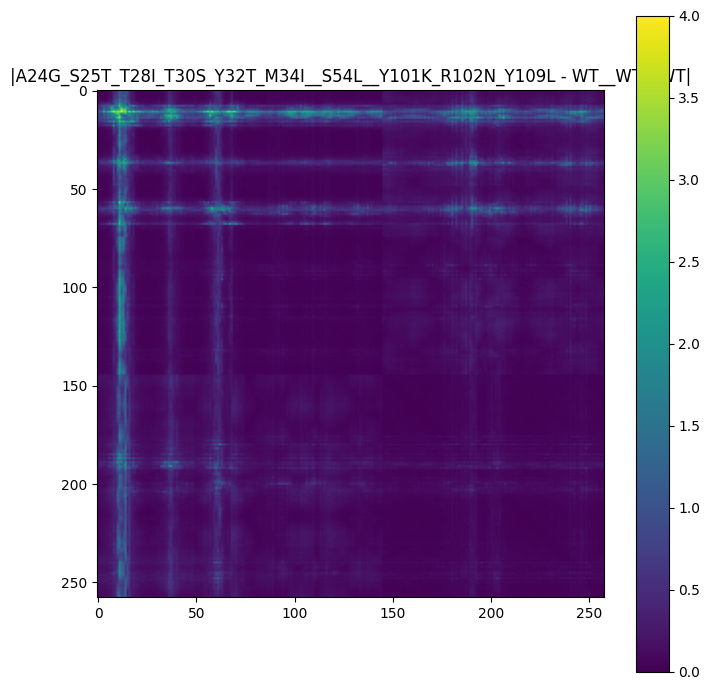

In [10]:
import torch
import matplotlib.pyplot as plt
from Bio import PDB
import re 

# --------------------------
# 1. Load tensors
# --------------------------
file_1 = "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/5ggs_optimab/5ggs_H_L_A_A24G_S25T_T28I_T30S_Y32T_M34I__S54L__Y101K_R102N_Y109L/pair.pt"
file_2 = "/home/psh/protein-frame-flow/inference_outputs/CDRFlow_v2.3.2.1_stage_2_ori_perturb_stage3/2025-12-06_22-56-57/epoch=52-step=75949_copy/5ggs_dms/5ggs_H_L_A_WT__WT__WT/pair.pt"
mt_1 = torch.load(file_1, map_location='cpu')
mt_2 = torch.load(file_2, map_location='cpu')

pure_mt_1 = file_1.split('/')[-2].replace("5ggs_H_L_A_", "")
pure_mt_2 = file_2.split('/')[-2].replace("5ggs_H_L_A_", "")

# --------------------------
# 2. Compute absolute mean difference
# --------------------------
tensor_2d = (mt_1['z'] - mt_2['z']).abs().mean(dim=-1)  # shape [L, L]
L = tensor_2d.shape[0]

# --------------------------
# 3. Load loop mask (no PDB mapping)
# --------------------------
loop_mask_1 = mt_1['loop_mask']  # [L]
loop_mask_2 = mt_2['loop_mask']  # [L]

print(loop_mask_1)

# CDR index list
cdr_indices = (loop_mask_1 == 1).nonzero(as_tuple=True)[0].tolist()

print("CDR index list:", cdr_indices)

# --------------------------
# Visualization
# --------------------------
fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(tensor_2d.cpu().numpy(), aspect='equal', vmin=0.0, vmax=4.0)
plt.colorbar(im, ax=ax)
ax.set_title(f"|{pure_mt_1} - {pure_mt_2}|")

146
plt.tight_layout()
plt.show()

## point mutation pairformer 가지고 t-sne를 진행